# 04 – Evaluation: Autoencoder för bedrägeridetektion

**Föregående steg:** `03_model_training.ipynb` tränade en autoencoder på enbart legitima transaktioner och sparade modellen (`../models/autoencoder.keras`) samt tröskelvärdet (`../models/threshold.json`, 95:e percentilen = 0,604441) baserat på validation-setet.

**Den här notebooken:** kör den tränade modellen mot det helt orörda testsetet (`X_test`, `y_test` från `splits.npz`) för första och enda gången, och utvärderar hur väl den upptäcker bedrägerier i praktiken.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import os

from src.data_utils import load_splits
from src.eval_utils import reconstruction_error, classify_by_threshold

os.makedirs('../reports/figures', exist_ok=True)


## Läs in modell, tröskel och testdata

In [2]:
splits = load_splits('../data/processed/splits.npz')
X_test = splits['X_test']
y_test = splits['y_test']

autoencoder = load_model('../models/autoencoder.keras')

with open('../models/threshold.json') as f:
    threshold_info = json.load(f)
threshold = threshold_info['threshold_value']

print("X_test:", X_test.shape)
print("y_test:", y_test.shape, "| Bedrägerier:", y_test.sum())
print("Tröskel:", threshold)


X_test: (56746, 30)
y_test: (56746,) | Bedrägerier: 95
Tröskel: 0.6044411063194275


**Vad ser vi?**

`X_test`: (56 746, 30) med 95 bedrägerier — matchar exakt det som sparades i `02_data_preparation.ipynb`. Tröskeln (0,6044411...) matchar `03_model_training.ipynb`. Testsetet och artefakterna är i synk.

## Beräkna rekonstruktionsfel på testsetet

Vi kör hela testsetet (legitima **och** bedrägliga transaktioner blandade) genom autoencodern och beräknar rekonstruktionsfelet (MSE) per rad. Transaktioner med fel över tröskeln klassificeras som misstänkta (1 = bedrägeri-flaggad, 0 = legitim).

In [3]:
mse_test = reconstruction_error(autoencoder, X_test)
y_pred = classify_by_threshold(mse_test, threshold)

print(f"Rekonstruktionsfel (test) — min: {mse_test.min():.4f}, max: {mse_test.max():.4f}, medel: {mse_test.mean():.4f}")
print(f"Antal flaggade som misstänkta: {y_pred.sum()} av {len(y_pred)} ({y_pred.mean()*100:.2f} %)")


Rekonstruktionsfel (test) — min: 0.0147, max: 95.9736, medel: 0.3033
Antal flaggade som misstänkta: 2954 av 56746 (5.21 %)


**Vad ser vi?**

Rekonstruktionsfelet på testdata sträcker sig från 0,0147 till 95,97 (medel 0,3033) — samma extremt högerskevda mönster som på validation. 2954 av 56 746 transaktioner (5,21 %) flaggas som misstänkta, vilket ligger mycket nära den förväntade ~5 % från tröskelns percentil-definition — bekräftar att tröskeln generaliserar väl från validation till det osedda testsetet.

## Confusion Matrix

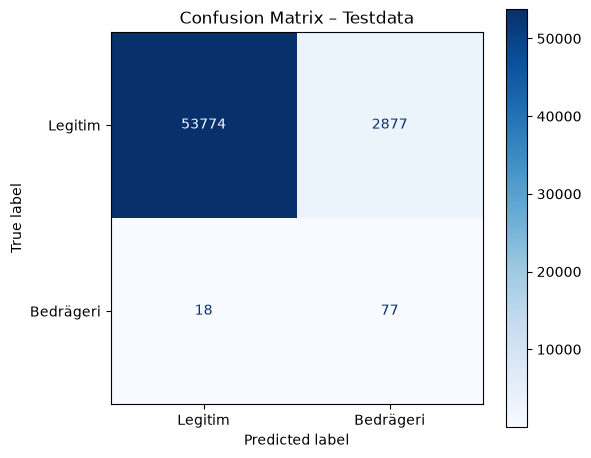

[[53774  2877]
 [   18    77]]


In [4]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitim', 'Bedrägeri'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix – Testdata')
plt.tight_layout()
plt.savefig('../reports/figures/07_confusion_matrix.png', dpi=150)
plt.show()

print(cm)


**Vad ser vi?**

|                | Predicerad Legitim | Predicerad Bedrägeri |
|----------------|--------------------|-----------------------|
| **Legitim**    | 53 774 (TN)        | 2 877 (FP)            |
| **Bedrägeri**  | 18 (FN)             | 77 (TP)               |

Modellen fångar **77 av 95 bedrägerier (81 %)** — en stark recall för en modell som aldrig sett en enda bedräglig transaktion under träning. Priset är 2 877 falska positiva (legitima transaktioner som flaggas i onödan), vilket är den förväntade avvägningen med en anomali-baserad ansats: modellen är bra på att fånga avvikelser, men "avvikande men legitimt" (ovanligt stora köp, ovanlig tid på dygnet, etc.) ser likadant ut för den som faktiskt bedrägeri.

## Classification Report

In [5]:
report_str = classification_report(y_test, y_pred, target_names=['Legitim', 'Bedrägeri'], digits=4)
print(report_str)

with open('../reports/classification_report.txt', 'w') as f:
    f.write(report_str)

report_dict = classification_report(y_test, y_pred, target_names=['Legitim', 'Bedrägeri'], digits=4, output_dict=True)

final_metrics = {
    'threshold': threshold,
    'accuracy': report_dict['accuracy'],
    'fraud_precision': report_dict['Bedrägeri']['precision'],
    'fraud_recall': report_dict['Bedrägeri']['recall'],
    'fraud_f1': report_dict['Bedrägeri']['f1-score'],
    'true_positives': int(cm[1, 1]),
    'false_negatives': int(cm[1, 0]),
    'false_positives': int(cm[0, 1]),
    'true_negatives': int(cm[0, 0]),
}
with open('../reports/final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print("\nSparat: reports/classification_report.txt och reports/final_metrics.json")


              precision    recall  f1-score   support

     Legitim     0.9997    0.9492    0.9738     56651
   Bedrägeri     0.0261    0.8105    0.0505        95

    accuracy                         0.9490     56746
   macro avg     0.5129    0.8799    0.5121     56746
weighted avg     0.9980    0.9490    0.9722     56746


Sparat: reports/classification_report.txt och reports/final_metrics.json


**Vad ser vi?**

- **Bedrägeri-recall: 81,05 %** — modellen fångar de allra flesta bedrägerier, vilket är det viktigaste måttet i den här kontexten (att missa bedrägerier är dyrare än att utreda falska larm)
- **Bedrägeri-precision: 2,61 %** — av alla transaktioner som flaggas är bara ~1 av 38 faktiskt bedrägeri. Det är förväntat med denna tröskelmetod och hanteras i praktiken genom ett andra filtreringssteg (manuell granskning eller en kompletterande modell)
- **Total accuracy: 94,90 %** — men det talet är i det närmaste meningslöst här: att gissa "legitim" på allting hade gett 99,83 % accuracy (se EDA) men fångat noll bedrägerier. Det är precisely därför recall/precision för minoritetsklassen är de mått som faktiskt spelar roll vid extrem klassobalans, inte total accuracy.

## Rekonstruktionsfel per klass

Vi visualiserar hur väl tröskeln separerar legitima och bedrägliga transaktioner i testsetet — idealt ska bedrägerier kluster till höger om tröskeln (högt rekonstruktionsfel) och legitima till vänster.

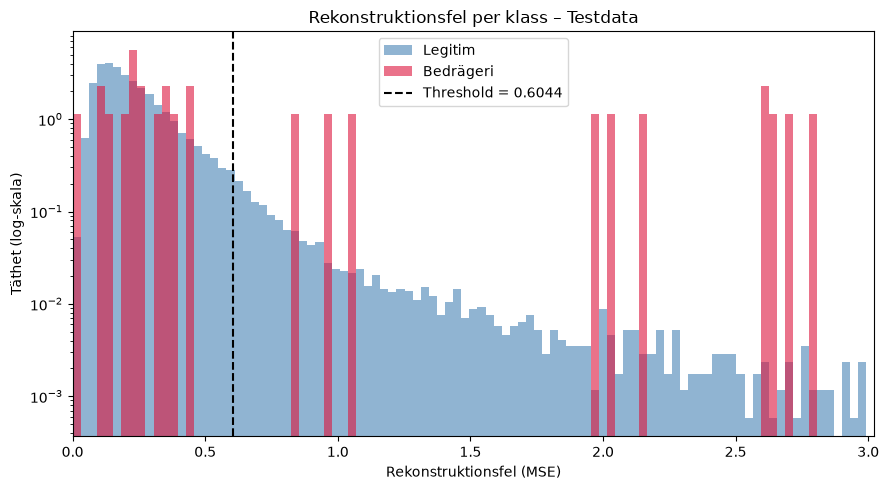

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

zoom_max = threshold * 5
bin_edges = np.linspace(0, zoom_max, 100)

ax.hist(mse_test[y_test == 0], bins=bin_edges, alpha=0.6, label='Legitim', color='steelblue', density=True)
ax.hist(mse_test[y_test == 1], bins=bin_edges, alpha=0.6, label='Bedrägeri', color='crimson', density=True)
ax.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
ax.set_yscale('log')
ax.set_xlim(0, zoom_max)
ax.set_xlabel('Rekonstruktionsfel (MSE)')
ax.set_ylabel('Täthet (log-skala)')
ax.set_title('Rekonstruktionsfel per klass – Testdata')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/08_test_reconstruction_by_class.png', dpi=150)
plt.show()


**Vad ser vi?**

Tydlig separation: den legitima fördelningen (blå) är starkt koncentrerad nära 0 och avtar snabbt med ökande rekonstruktionsfel. Bedrägerierna (röda staplar, glesa eftersom det bara är 95 observationer) sprider sig över hela intervallet — några ligger under tröskeln (de 18 missade, false negatives), men majoriteten ligger bortom tröskeln ända ut till MSE ~3, vilket bekräftar den höga recall-siffran (81 %). Det finns ett tydligt överlapp strax kring tröskeln (0,1–0,6), vilket är precis den zon där avvägningen mellan recall och precision avgörs — en lägre tröskel skulle fånga fler av de 18 missade bedrägerierna men till priset av ännu fler falska positiva bland de redan 2877.

## Sammanfattning

- **Recall (bedrägeri):** 81,05 % — 77 av 95 bedrägerier fångade
- **Precision (bedrägeri):** 2,61 % — 2 877 falska positiva bland 2 954 flaggade transaktioner
- **F1-score (bedrägeri):** 0,0505
- **Accuracy:** 94,90 % (missvisande mått givet klassobalansen — se diskussion ovan)
- **Andel flaggade transaktioner:** 5,21 % av testsetet, i linje med den förväntade ~5 % från tröskelns percentil-definition

**Slutsats:** En autoencoder tränad enbart på legitima transaktioner fångar en stor majoritet av bedrägerierna utan att någonsin ha sett ett enda exempel på bedrägeri under träning — en tydlig demonstration av anomali-detektering. Avvägningen är ett stort antal falska positiva, vilket i en verklig tillämpning skulle hanteras med ett andra filtreringssteg.

**Sparade artefakter:**
- `../reports/figures/07_confusion_matrix.png`
- `../reports/figures/08_test_reconstruction_by_class.png`
- `../reports/classification_report.txt`
- `../reports/final_metrics.json`

**Nästa steg:** Bygg PowerPoint-presentationen (databerättelse, ~15 min) utifrån figurerna och siffrorna i `reports/`.